First model submission (simple baseline regression)

Step #1 – Set up notebook and import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_log_error
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt
import seaborn as sns



Step #2 – Load datasets

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

train.head()



,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


Step 3 — Encode categorical column (“Sex”)
RandomForest cannot handle strings like 'M', 'F', 'I'.

In [3]:
# Identify categorical column
cat_cols = ['Sex']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_train = encoder.fit_transform(train[cat_cols])
encoded_test = encoder.transform(test[cat_cols])

encoded_train_df = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(cat_cols))
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(cat_cols))

# Drop original categorical column
train2 = train.drop(columns=cat_cols)
test2 = test.drop(columns=cat_cols)

# Add encoded columns
train2 = pd.concat([train2, encoded_train_df], axis=1)
test2 = pd.concat([test2, encoded_test_df], axis=1)



Step #4 – Define features and target

In [4]:
target_col = "Rings"
feature_cols = [c for c in train2.columns if c != target_col]

X = train2[feature_cols]
y = train2[target_col]
X_test = test2[feature_cols]



Step #5 – Train/validation split for model evaluation

In [5]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Step #6 – Fit first model Train Random Forest model

In [6]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Validation predictions
y_valid_pred = rf.predict(X_valid)

# RMSLE on validation
rmsle = np.sqrt(mean_squared_log_error(y_valid, y_valid_pred))
print("RandomForest RMSLE (validation):", rmsle)


RandomForest RMSLE (validation): 0.15520840534624417


Step #7 – Check residuals and basic assumptions

C:\Users\sjrey\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


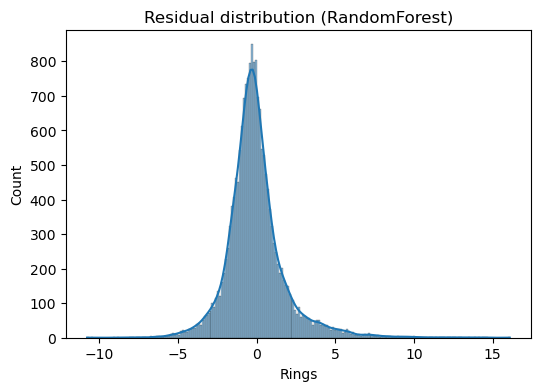

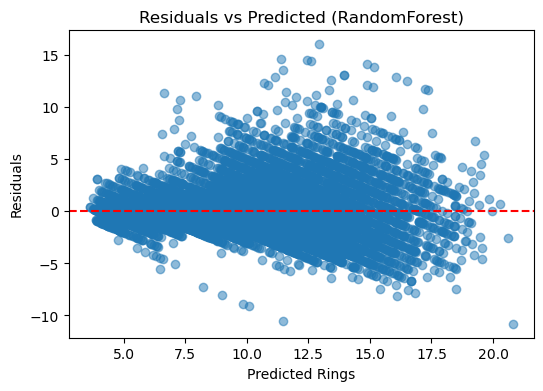

In [7]:
residuals = y_valid - y_valid_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual distribution (RandomForest)")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_valid_pred, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Rings")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (RandomForest)")
plt.show()


Step #8 – Train on full training data and predict on test

In [8]:
rf_full = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_full.fit(X, y)

test_pred_rf = rf_full.predict(X_test)


Step #9 – Create first Kaggle submission file

In [9]:
submission_rf = sample_submission.copy()
submission_col = submission_rf.columns[-1]  # last column is usually target

submission_rf[submission_col] = test_pred_rf

submission_rf.to_csv("submission_rf.csv", index=False)
print("First submission file saved as submission_rf.csv")


First submission file saved as submission_rf.csv
